In [1]:
import numpy as np

In [2]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([40, 50, 60, 70, 80])

w = 0.0  # beta 1 written as w slope
b = 0.0  # beta 0 as b bias (intercept)

learning_rate = 0.01
epochs = 1000


In [3]:

def predict(x, w, b):
    return w * x + b

# cost function (MSE)
def cost_function(x, y, w, b):
    y_pred = predict(x, w, b)
    cost = np.mean((y - y_pred) ** 2)
    return cost

# Gradient calculation
def gradient(x, y, w, b):
    n = len(x)
    y_pred = predict(x, w, b)
    dw = (-2 / n) * np.sum(x * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)
    return dw, db

In [4]:
# storing the record
cost_history = []
weight_history = []
bias_history = []
dw_history = []
db_history = []

for epoch in range(epochs):
    dw, db = gradient(x, y, w, b)
    dw_history.append(dw)
    db_history.append(db)
    
    # update value of w and b
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # store history
    cost_history.append(cost_function(x, y, w, b))
    weight_history.append(w)
    bias_history.append(b)

    if epoch % 100 == 0:
        # Fixed `:4b` to `:4f` here
        print(f"Epoch {epoch:4d} | cost={cost_history[-1]:.4f} | weight={w:.4f} | bias={b:.4f}")

print("--- Training Complete ---")
print("-------------------------")
print("Final weight :", round(w, 4))
print("Final bias :", round(b, 4))

# --------
print("\nPrediction")
prediction = predict(x, w, b)
for i, actual, pred in zip(x, y, prediction):
    print(f"Hours={int(i)} | Actual={actual:.1f} | Prediction={pred:.2f}")


Epoch    0 | cost=2262.2400 | weight=4.0000 | bias=1.2000
Epoch  100 | cost=58.7357 | weight=14.9756 | bias=12.0364
Epoch  200 | cost=29.8358 | weight=13.5462 | bias=17.1970
Epoch  300 | cost=15.1556 | weight=12.5275 | bias=20.8751
Epoch  400 | cost=7.6986 | weight=11.8014 | bias=23.4965
Epoch  500 | cost=3.9106 | weight=11.2839 | bias=25.3648
Epoch  600 | cost=1.9865 | weight=10.9150 | bias=26.6964
Epoch  700 | cost=1.0091 | weight=10.6522 | bias=27.6455
Epoch  800 | cost=0.5126 | weight=10.4648 | bias=28.3219
Epoch  900 | cost=0.2604 | weight=10.3313 | bias=28.8040
--- Training Complete ---
-------------------------
Final weight : 10.2369
Final bias : 29.1447

Prediction
Hours=1 | Actual=40.0 | Prediction=39.38
Hours=2 | Actual=50.0 | Prediction=49.62
Hours=3 | Actual=60.0 | Prediction=59.86
Hours=4 | Actual=70.0 | Prediction=70.09
Hours=5 | Actual=80.0 | Prediction=80.33


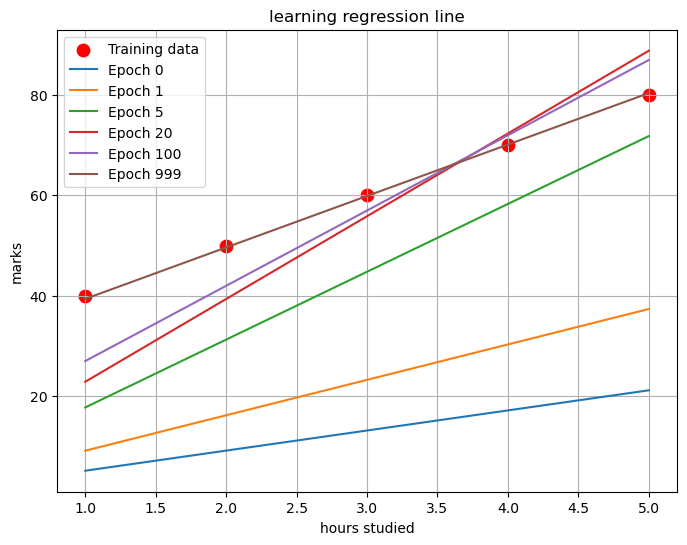

In [5]:

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(x,y,color='red',s=80,label='Training data')
epochs_to_show=[0,1,5,20,100,999]
for e in epochs_to_show:
    y=weight_history[e]*x+bias_history[e]
    plt.plot(x,y,label=f"Epoch {e}")
plt.title("learning regression line")
plt.xlabel("hours studied")
plt.ylabel("marks")
plt.legend()
plt.grid()
plt.show()
